In [1]:
from pathlib import Path
import pickle

import numpy as np

# ComputeInteraction -- ci.run() / ci.combine()

- Run RR, RD, DD, and combined to crate an InteractionNetwork object
- compare these outputs
  - intermediate/ssM_mhygessi_RR_R0.pkl
  - intermediate/ssM_mhygessi_RD_R0.pkl
  - intermediate/ssM_mhygessi_DD_R0.pkl
  - intermediate/ssM_mhygessi_combined_R0.pkl

In [2]:
ground_truth_result_dir = Path("/home/fisch872/mat/projects/BridGE-Python/testdata/intermediate")
new_results_dir = Path("/home/fisch872/mat/projects/BridGE-Python-AoU/testing/intermediate")
R = 5

In [ ]:
for i in range(R + 1):
    files_list = [
        f"ssM_mhygessi_RR_R{i}.pkl",
        f"ssM_mhygessi_RD_R{i}.pkl",
        f"ssM_mhygessi_DD_R{i}.pkl",
        f"ssM_mhygessi_combined_R{i}.pkl",
        ]

    for file_name in files_list:
        with open(ground_truth_result_dir / file_name, 'rb') as f:
            old_res_network = pickle.load(f)
        
        with open(new_results_dir / file_name, 'rb') as f:
            new_res_network = pickle.load(f)
            
        new_protective = new_res_network.protective.toarray()
        new_risk = new_res_network.risk.toarray()
        
        test1 = np.allclose(old_res_network.protective, new_protective)
        test2 = np.allclose(old_res_network.risk, new_risk)
        
        if "combined" in file_name:
            test3 = np.array_equal(old_res_network.protective_max_id, new_res_network.protective_max_id.toarray())
            test4 = np.array_equal(old_res_network.risk_max_id, new_res_network.risk_max_id.toarray())
        else:
            test3 = True
            test4 = True
        
        # make sure that the results are not too small in that np.allclose isn't meaningful
        # how many values are below 1e-8 and aren't zero?
        test5 = np.sum((new_protective < 1e-8) & (new_protective != 0)) == 0
        test6 = np.sum((new_risk < 1e-8) & (new_risk != 0)) == 0
        
        print(f"{file_name} - {all([test1, test2, test3, test4, test5, test6])}")
        
        if not all([test1, test2, test3, test4, test5, test6]):
            for i, test_var in enumerate([test1, test2, test3, test4, test5, test6], start=1):
                if not test_var:
                    print(f"\tTest {i} failed")
    print()
    
# the only fails are in the max ids
# differences arise do to the fact that the hypergeometric is more accurate
# which gives different max ids depending on how small the difference is between the -log10(pvalues)

ssM_mhygessi_RR_R0.pkl - True
ssM_mhygessi_RD_R0.pkl - True
ssM_mhygessi_DD_R0.pkl - True
ssM_mhygessi_combined_R0.pkl - True

ssM_mhygessi_RR_R1.pkl - True
ssM_mhygessi_RD_R1.pkl - True
ssM_mhygessi_DD_R1.pkl - True
ssM_mhygessi_combined_R1.pkl - False
	Test 3 failed

ssM_mhygessi_RR_R2.pkl - True
ssM_mhygessi_RD_R2.pkl - True
ssM_mhygessi_DD_R2.pkl - True
ssM_mhygessi_combined_R2.pkl - False
	Test 3 failed

ssM_mhygessi_RR_R3.pkl - True
ssM_mhygessi_RD_R3.pkl - True
ssM_mhygessi_DD_R3.pkl - True
ssM_mhygessi_combined_R3.pkl - False
	Test 3 failed

ssM_mhygessi_RR_R4.pkl - True
ssM_mhygessi_RD_R4.pkl - True
ssM_mhygessi_DD_R4.pkl - True
ssM_mhygessi_combined_R4.pkl - True

ssM_mhygessi_RR_R5.pkl - True
ssM_mhygessi_RD_R5.pkl - True
ssM_mhygessi_DD_R5.pkl - True
ssM_mhygessi_combined_R5.pkl - False
	Test 3 failed
	Test 4 failed



In [4]:
# just look into combined...why isn't this working?

for i in range(R + 1):
    i = 5
    file_name = f"ssM_mhygessi_combined_R{i}.pkl"
 
    with open(ground_truth_result_dir / file_name, 'rb') as f:
        old_res_network = pickle.load(f)
    
    with open(new_results_dir / file_name, 'rb') as f:
        new_res_network = pickle.load(f)
        
    new_protective = new_res_network.protective.toarray()
    new_risk = new_res_network.risk.toarray()
    
    test1 = np.allclose(old_res_network.protective, new_protective)
    test2 = np.allclose(old_res_network.risk, new_risk)
    test3 = np.array_equal(old_res_network.protective_max_id, new_res_network.protective_max_id.toarray())
    test4 = np.array_equal(old_res_network.risk_max_id, new_res_network.risk_max_id.toarray())
    # make sure that the results are not too small in that np.allclose isn't meaningful
    # how many values are below 1e-8 and aren't zero?
    test5 = np.sum((new_protective < 1e-8) & (new_protective != 0)) == 0
    test6 = np.sum((new_risk < 1e-8) & (new_risk != 0)) == 0

    print(f"{file_name} - {all([test1, test2, test3, test4, test5, test6])}")
        
    if not all([test1, test2, test3, test4, test5, test6]):
        for i, test_var in enumerate([test1, test2, test3, test4, test5, test6], start=1):
            if not test_var:
                print(f"\tTest {i} failed")
    print()
    break

ssM_mhygessi_combined_R5.pkl - False
	Test 3 failed
	Test 4 failed



In [5]:
# recreate the combined network using new data with old technique to see if it matches the old combined network

def old_combine(project_dir, R):
    ## load results for 3 models
    with open(f"{project_dir}/ssM_mhygessi_RR_R{R}.pkl", 'rb') as rr_file:
        rr_network = pickle.load(rr_file)
    with open(f"{project_dir}/ssM_mhygessi_RD_R{R}.pkl", 'rb') as rd_file:
        rd_network = pickle.load(rd_file)
    with open(f"{project_dir}/ssM_mhygessi_DD_R{R}.pkl", 'rb') as dd_file:
        dd_network = pickle.load(dd_file)

    s = rr_network.risk.shape[0]

    ## compare netowrks, take the element-wise max
    risk_max_id = np.zeros((s,s))
    risk_max_id[rr_network.risk > dd_network.risk ] = 1
    risk_max_id[risk_max_id==0] = 2
    risk_max_temp = np.maximum(rr_network.risk,dd_network.risk)
    risk_max_id[risk_max_temp<rd_network.risk] = 3
    risk_max = np.maximum(risk_max_temp,rd_network.risk)
    risk_max_id[risk_max==0] = 0

    protective_max_id = np.zeros((s,s))
    protective_max_id[rr_network.protective > dd_network.protective] = 1
    protective_max_id[protective_max_id==0] = 2
    protective_max_temp = np.maximum(rr_network.protective,dd_network.protective)
    protective_max_id[protective_max_temp<rd_network.protective] = 3
    protective_max = np.maximum(protective_max_temp,rd_network.protective)
    protective_max_id[protective_max==0] = 0
    
    return risk_max, protective_max, risk_max_id, protective_max_id, rr_network, rd_network, dd_network

def combine_max(rr, rd, dd):
    # elementwise max across the three — already sparse-native (unchanged from your code)
    network_max_temp = rr.maximum(dd)
    network_max = network_max_temp.maximum(rd)

    # strict inequalities between sparse arrays stay sparse (unlike >=, <=, ==, !=)
    cond3 = network_max_temp < rd   # rd is strictly the overall max
    cond1 = rr > dd                 # rr > dd

    # "cond1 AND NOT cond3": subtract the overlap instead of negating (negation would densify)
    cond1_final = cond1 - cond1.multiply(cond3)

    # nonzero pattern of the overall max, replacing the dense zero-out step
    pattern = network_max.astype(bool)

    region_13 = cond1_final + cond3
    region_2 = pattern - region_13          # "else" case: dd wins (or tie), within the nonzero pattern

    network_max_id = (cond1_final + region_2.multiply(2) + cond3.multiply(3))
    network_max_id.eliminate_zeros()
    
    return network_max, network_max_id

def new_combine(project_dir, R):
    ## load results for 3 models
    with open(f"{project_dir}/ssM_mhygessi_RR_R{R}.pkl", 'rb') as rr_file:
        rr_network = pickle.load(rr_file)
    with open(f"{project_dir}/ssM_mhygessi_RD_R{R}.pkl", 'rb') as rd_file:
        rd_network = pickle.load(rd_file)
    with open(f"{project_dir}/ssM_mhygessi_DD_R{R}.pkl", 'rb') as dd_file:
        dd_network = pickle.load(dd_file)

    risk_max, risk_max_id = combine_max(rr_network.risk, rd_network.risk, dd_network.risk)
    protective_max, protective_max_id = combine_max(rr_network.protective, rd_network.protective, dd_network.protective)
    
    return risk_max, protective_max, risk_max_id, protective_max_id, rr_network, rd_network, dd_network


In [6]:
old_risk_max, old_protective_max, old_risk_max_id, old_protective_max_id, old_rr_network, old_rd_network, old_dd_network = old_combine(ground_truth_result_dir, 5)
new_risk_max, new_protective_max, new_risk_max_id, new_protective_max_id, new_rr_network, new_rd_network, new_dd_network = new_combine(new_results_dir, 5)

In [7]:
np.allclose(old_risk_max, new_risk_max.toarray())

True

In [8]:
np.allclose(old_protective_max, new_protective_max.toarray())

True

In [9]:
np.array_equal(old_risk_max_id, new_risk_max_id.toarray())

False

In [10]:
np.array_equal(old_protective_max_id, new_protective_max_id.toarray())

False

In [14]:
a = old_risk_max_id
b = new_risk_max_id.toarray()
for pos in zip(*np.where(a != b)):
    print(pos, a[pos], b[pos])
    print(old_risk_max[pos], new_risk_max[pos])                  # combined
    print(old_rr_network.risk[pos], new_rr_network.risk[pos])    # RR - 1
    print(old_rd_network.risk[pos], new_rd_network.risk[pos])    # RD - 3
    print(old_dd_network.risk[pos], new_dd_network.risk[pos])    # DD - 2
    print()
    print(old_risk_max[pos] == new_risk_max[pos])                # combined
    print(old_rr_network.risk[pos] == new_rr_network.risk[pos])  # RR - 1
    print(old_rd_network.risk[pos] == new_rd_network.risk[pos])  # RD - 3
    print(old_dd_network.risk[pos] == new_dd_network.risk[pos])  # DD - 2
    print()
    print(old_risk_max[pos] == old_rd_network.risk[pos])
    print(new_risk_max[pos] == new_rr_network.risk[pos])
    break


# (np.int64(7228), np.int64(14919)) 3.0 1
# 1.213956931529898  1.2139569315349183    combined     Not the same
# 1.2139569315298329 1.2139569315349183    RR - 1       Not the same
# 1.213956931529898  1.2139569315349183    RD - 3       Not the same
# 0.0                0.0                   DD - 2       Is the same

# accurate up until 10 decimal places.

# Questions for Chad/Wen
# when calculating combined, which takes the max of the three networks...
# How to choose a max network ID if two networks have the same value?
# How closely do we decide if a value is larger than another, especially since the difference between values is very small

(np.int64(7228), np.int64(14919)) 3.0 1
1.213956931529898 1.213956931534918
1.2139569315298329 1.213956931534918
1.213956931529898 1.213956931534918
0.0 0.0

False
False
False
True

True
True


# ComputeStats -- genstats()

- Use the interaction network to calculate statistical tests on ... to create a GenstatsOut object that is made up of two Stats objects, one for protective and one for risk.
- compare these outputs
  - intermediate/genstats_ssM_mhygessi_combined_R0.pkl
  - there will be a set of stats for each protective and risk networks



- genstats_perm_optimized.py
- README_optimizations.md
- test_compare.py
- test_compare_scale.py
- rungenstats_variants.py
- genstats_core.py

In [4]:
ground_truth_result_dir = Path("/home/fisch872/mat/projects/BridGE-Python/testdata/intermediate")
new_results_dir = Path("/home/fisch872/mat/projects/BridGE-Python-AoU/testing/intermediate")
R = 5

In [5]:
for i in range(R + 1):
    print(i)
    
    prot_res = []
    risk_res = []
    
    file_name = f"genstats_ssM_mhygessi_combined_R{i}.pkl"

    with open(ground_truth_result_dir / file_name, 'rb') as f:
        old_res = pickle.load(f)
    old_prot = old_res.protective_stats
    old_risk = old_res.risk_stats
    
    with open(new_results_dir / file_name, 'rb') as f:
        new_res = pickle.load(f)
    new_prot = new_res.protective_stats
    new_risk = new_res.risk_stats
    
    prot_res.append(np.allclose(old_prot.bpm_local, new_prot.bpm_local))
    prot_res.append(np.allclose(old_prot.bpm_local_pv, new_prot.bpm_local_pv))  # 2
    prot_res.append(np.allclose(old_prot.density_bpm, new_prot.density_bpm))
    prot_res.append(np.allclose(old_prot.density_bpm_expected, new_prot.density_bpm_expected))
    prot_res.append(np.allclose(old_prot.dense_index, new_prot.dense_index))
    prot_res.append(np.allclose(old_prot.wpm_local, new_prot.wpm_local))
    prot_res.append(np.allclose(old_prot.wpm_local_pv, new_prot.wpm_local_pv))  # 7
    prot_res.append(np.allclose(old_prot.density_wpm, new_prot.density_wpm))
    prot_res.append(np.allclose(old_prot.density_wpm_expected, new_prot.density_wpm_expected))
    prot_res.append(np.allclose(old_prot.path_degree, new_prot.path_degree))
    prot_res.append(np.allclose(old_prot.path_degree_pv, new_prot.path_degree_pv))  # 11

    risk_res.append(np.allclose(old_risk.bpm_local, new_risk.bpm_local))
    risk_res.append(np.allclose(old_risk.bpm_local_pv, new_risk.bpm_local_pv))  # 2
    risk_res.append(np.allclose(old_risk.density_bpm, new_risk.density_bpm))
    risk_res.append(np.allclose(old_risk.density_bpm_expected, new_risk.density_bpm_expected))
    risk_res.append(np.allclose(old_risk.dense_index, new_risk.dense_index))
    risk_res.append(np.allclose(old_risk.wpm_local, new_risk.wpm_local))
    risk_res.append(np.allclose(old_risk.wpm_local_pv, new_risk.wpm_local_pv))  # 7
    risk_res.append(np.allclose(old_risk.density_wpm, new_risk.density_wpm))
    risk_res.append(np.allclose(old_risk.density_wpm_expected, new_risk.density_wpm_expected))
    risk_res.append(np.allclose(old_risk.path_degree, new_risk.path_degree))
    risk_res.append(np.allclose(old_risk.path_degree_pv, new_risk.path_degree_pv))  # 11

    print(f"protective tests: {all(prot_res)}")
    for j, tmp_res in enumerate(prot_res, start=1):
        if not tmp_res:
            print(f"\ttest {j} failed")
            
    print(f"risk tests: {all(risk_res)}")
    for j, tmp_res in enumerate(risk_res, start=1):
        if not tmp_res:
            print(f"\ttest {j} failed")
    
# all pass except uniformly for bpm_local_pv, wpm_local_pv, and path_degree_pv
# but these are from the permutations. How the original was configured is that the
# permutation seed would be different depending on how many n_workers you used, 
# so in the end it isn't reproducible across different number of workers.
# everything else in the new code is correct. 

# Also, the plan is to have the permutations not be set by individual workers but rather do it globally
# so that the permutations are the same regardless of how many workers you use. 

0
protective tests: False
	test 2 failed
	test 7 failed
	test 11 failed
risk tests: False
	test 2 failed
	test 7 failed
	test 11 failed
1
protective tests: False
	test 2 failed
	test 7 failed
	test 11 failed
risk tests: False
	test 2 failed
	test 7 failed
	test 11 failed
2
protective tests: False
	test 2 failed
	test 7 failed
	test 11 failed
risk tests: False
	test 2 failed
	test 7 failed
	test 11 failed
3
protective tests: False
	test 2 failed
	test 7 failed
	test 11 failed
risk tests: False
	test 2 failed
	test 7 failed
	test 11 failed
4
protective tests: False
	test 2 failed
	test 7 failed
	test 11 failed
risk tests: False
	test 2 failed
	test 7 failed
	test 11 failed
5
protective tests: False
	test 2 failed
	test 7 failed
	test 11 failed
risk tests: False
	test 2 failed
	test 7 failed
	test 11 failed


In [60]:
file_name = f"genstats_ssM_mhygessi_combined_R0.pkl"

with open(ground_truth_result_dir / file_name, 'rb') as f:
    old_res = pickle.load(f)
old_prot = old_res.protective_stats
old_risk = old_res.risk_stats

with open(new_results_dir / file_name, 'rb') as f:
    new_res = pickle.load(f)
new_prot = new_res.protective_stats
new_risk = new_res.risk_stats

prot_res = []
prot_res.append(np.allclose(old_prot.bpm_local_pv, new_prot.bpm_local_pv))
prot_res.append(np.allclose(old_prot.wpm_local_pv, new_prot.wpm_local_pv))
prot_res.append(np.allclose(old_prot.path_degree_pv, new_prot.path_degree_pv))

risk_res = []
risk_res.append(np.allclose(old_risk.bpm_local_pv, new_risk.bpm_local_pv))
risk_res.append(np.allclose(old_risk.wpm_local_pv, new_risk.wpm_local_pv))
risk_res.append(np.allclose(old_risk.path_degree_pv, new_risk.path_degree_pv))

In [61]:
old_prot.bpm_local_pv

array([1., 1., 1., ..., 1., 1., 1.], shape=(1353835,))

In [62]:
new_prot.bpm_local_pv

array([1., 1., 1., ..., 1., 1., 1.], shape=(1353835,))

In [63]:
a = old_prot.bpm_local_pv
b = new_prot.bpm_local_pv

# how many aren't correct
print(len(np.where(a != b)[0]))

# how many in each aren't value=1
print(len(np.where((a == 1))[0]))
print(len(np.where((b == 1))[0]))

# how many aren't value=1 and aren't correct?
print(len(np.where((a != b) & (a != 1) & (b != 1))[0]))

count = 0
for pos in zip(*np.where(a != b)):
    print(pos, a[pos], b[pos])
    if count > 10:
        break
    count += 1

84022
1259015
1259015
84022
(np.int64(22),) 0.26 0.21
(np.int64(35),) 0.43 0.27
(np.int64(64),) 0.36 0.26
(np.int64(110),) 0.46 0.4
(np.int64(148),) 0.41 0.3
(np.int64(184),) 0.16 0.13
(np.int64(307),) 0.05 0.06
(np.int64(325),) 0.2 0.19
(np.int64(400),) 0.42 0.31
(np.int64(482),) 0.26 0.23
(np.int64(550),) 0.27 0.18
(np.int64(581),) 0.23 0.14


In [64]:
np.where(a != b)[0]

array([     22,      35,      64, ..., 1353760, 1353766, 1353827],
      shape=(84022,))

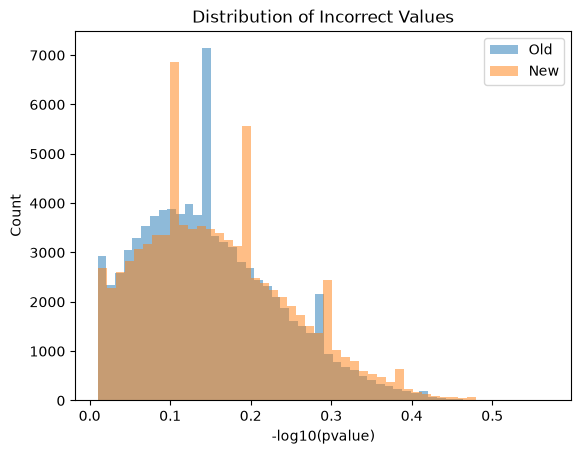

In [65]:
# plot distribution of incorrect values
from matplotlib import pyplot as plt

mask = np.where(a != b)[0]

plt.hist(a[mask], bins=50, alpha=0.5, label='Old')
plt.hist(b[mask], bins=50, alpha=0.5, label='New')
plt.xlabel('-log10(pvalue)')
plt.ylabel('Count')
plt.title('Distribution of Incorrect Values')
plt.legend()
plt.show()

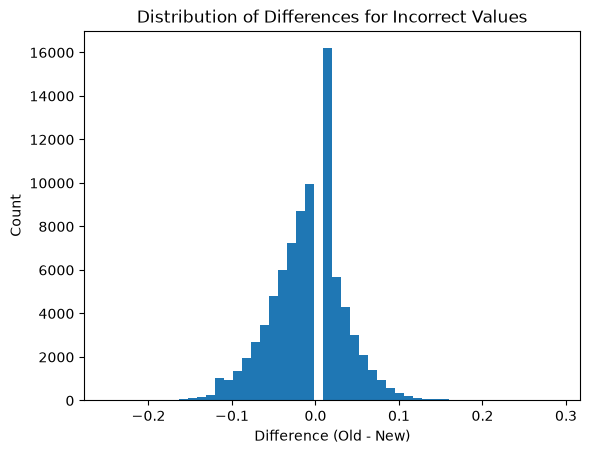

In [66]:
# plot the differences of values as a histograms

mask = np.where(a != b)[0]

plt.hist(a[mask] - b[mask], bins=50)
plt.xlabel('Difference (Old - New)')
plt.ylabel('Count')
plt.title('Distribution of Differences for Incorrect Values')
plt.show()

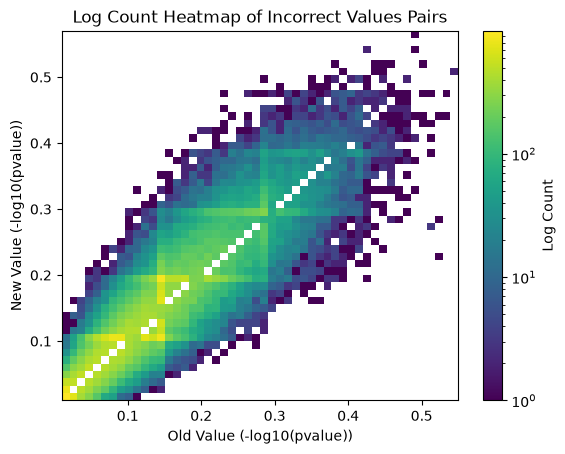

In [67]:
# now make the same heatmap plot but show as a binary indicator if that hexbin has any differences or not
from matplotlib.colors import LogNorm

plt.hist2d(a[mask], b[mask], bins=50, norm=LogNorm())
plt.colorbar(label='Log Count')
plt.xlabel('Old Value (-log10(pvalue))')
plt.ylabel('New Value (-log10(pvalue))')
plt.title('Log Count Heatmap of Incorrect Values Pairs')
plt.show()

# ComputeFDR -- fdrsampleperm()

- fdrsampleperm.py
- fdrsampleperm_baseline_reference.py
- gen_synthetic.py
- compare_test.py

In [6]:
ground_truth_result_dir = Path("/home/fisch872/mat/projects/BridGE-Python/testdata/intermediate")
new_results_dir = Path("/home/fisch872/mat/projects/BridGE-Python-AoU/testing/intermediate")

In [ ]:
file_name = f"results_ssM_mhygessi_combined_R0.pkl"

with open(ground_truth_result_dir / file_name, 'rb') as f:
    old_res = pickle.load(f)

with open(new_results_dir / file_name, 'rb') as f:
    new_res = pickle.load(f)

compare_res = []

compare_res.append(np.array_equiv(old_res.bpm_pv,          new_res.bpm_pv))
compare_res.append(np.array_equiv(old_res.wpm_pv,          new_res.wpm_pv))
compare_res.append(np.array_equiv(old_res.path_pv,         new_res.path_pv))

compare_res.append(np.array_equiv(old_res.bpm_ranksum,     new_res.bpm_ranksum))
compare_res.append(np.array_equiv(old_res.wpm_ranksum,     new_res.wpm_ranksum))
compare_res.append(np.array_equiv(old_res.path_ranksum,    new_res.path_ranksum))

compare_res.append(np.array_equiv(old_res.fdrbpm1,         new_res.fdrbpm1))  # 7
compare_res.append(np.array_equiv(old_res.fdrbpm2,         new_res.fdrbpm2))  # 8
compare_res.append(np.array_equiv(old_res.fdrwpm1,         new_res.fdrwpm1))

compare_res.append(np.array_equiv(old_res.fdrwpm2,         new_res.fdrwpm2))
compare_res.append(np.array_equiv(old_res.fdrpath1,        new_res.fdrpath1))  # 10
compare_res.append(np.array_equiv(old_res.fdrpath2,        new_res.fdrpath2))  # 11

print(f"tests: {all(compare_res)}")
for j, tmp_res in enumerate(compare_res, start=1):
    if not tmp_res:
        print(f"\ttest {j} failed")
    
# the arrays are not exact

tests: False
	test 7 failed
	test 8 failed
	test 10 failed
	test 11 failed


In [ ]:
file_name = f"results_ssM_mhygessi_combined_R0.pkl"
tmp_atol = 1e-16
tmp_rtol = 1e-10
# twice the tolerance than default

with open(ground_truth_result_dir / file_name, 'rb') as f:
    old_res = pickle.load(f)

with open(new_results_dir / file_name, 'rb') as f:
    new_res = pickle.load(f)

compare_res = []

compare_res.append(np.allclose(old_res.bpm_pv, new_res.bpm_pv, atol=tmp_atol, rtol=tmp_rtol))  
compare_res.append(np.allclose(old_res.wpm_pv, new_res.wpm_pv, atol=tmp_atol, rtol=tmp_rtol))
compare_res.append(np.allclose(old_res.path_pv, new_res.path_pv, atol=tmp_atol, rtol=tmp_rtol))

compare_res.append(np.allclose(old_res.bpm_ranksum, new_res.bpm_ranksum, atol=tmp_atol, rtol=tmp_rtol))
compare_res.append(np.allclose(old_res.wpm_ranksum, new_res.wpm_ranksum, atol=tmp_atol, rtol=tmp_rtol))
compare_res.append(np.allclose(old_res.path_ranksum, new_res.path_ranksum, atol=tmp_atol, rtol=tmp_rtol))

compare_res.append(np.allclose(old_res.fdrbpm1, new_res.fdrbpm1, atol=tmp_atol, rtol=tmp_rtol))
compare_res.append(np.allclose(old_res.fdrbpm2, new_res.fdrbpm2, atol=tmp_atol, rtol=tmp_rtol))
compare_res.append(np.allclose(old_res.fdrwpm1, new_res.fdrwpm1, atol=tmp_atol, rtol=tmp_rtol))

compare_res.append(np.allclose(old_res.fdrwpm2, new_res.fdrwpm2, atol=tmp_atol, rtol=tmp_rtol))
compare_res.append(np.allclose(old_res.fdrpath1, new_res.fdrpath1, atol=tmp_atol, rtol=tmp_rtol))
compare_res.append(np.allclose(old_res.fdrpath2, new_res.fdrpath2, atol=tmp_atol, rtol=tmp_rtol))

print(f"tests: {all(compare_res)}")
for j, tmp_res in enumerate(compare_res, start=1):
    if not tmp_res:
        print(f"\ttest {j} failed")
    
# but they are very close

tests: True


# Summarize

excel files are the same